<fieldset style="padding:10px; border:1px solid #ccc; box-shadow:2px 2px 5px rgba(0,0,0,0.1);">
<legend style="font-size: 10px; color:#555;">Credits</legend>

<table style="width: 100%; border-collapse: collapse;">
    <tr>
        <td style="width: 80px; vertical-align: top;">
            <img src="https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/logo/logo_b_text_lowres.png" alt="AstroStat Academy logo" width="100">
        </td>
        <td style="vertical-align: center; padding-left: 15px; font-size: 10px; line-height: 1.2;">
            This notebook contains original work by the authors unless stated otherwise.
            Any external material is properly credited to its sources.<br>
            References to papers, datasets, and software are acknowledged.
            Original content is licensed under the <a href="https://www.gnu.org/licenses/gpl-3.0.en.html">GNU General Public License v3.0 (GNU GPLv3)</a>.
        </td>
    </tr>
</table>

</fieldset>
<!-- Allow these <br> or it will look ugly once rendered on Jupyter Book. -->
<br>

# Convolutional Neural Networks

In this workshop we see

- what **CNNs are**
- some of their basic **components**
- how we **build a model** that will classify images.



## Setup

In [1]:
import numpy as np
import matplotlib
import matplotlib.pyplot as plt

from IPython.display import display, HTML
display(HTML("<style>.container { width:100% !important; }</style>"))

import requests

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/colab/clone_and_cd_colab.py"
colab = requests.get(url).text
exec(colab)

url = "https://raw.githubusercontent.com/AstroStat-Academy/assets-public/main/styles/plot_style.py"
style = requests.get(url).text
exec(style)

import warnings
warnings.filterwarnings(action='ignore')


import scipy.io as scio
import keras
from IPython.display import clear_output
import keras.utils as ult
from keras.layers import Activation, Dropout, Flatten, Dense, Input, BatchNormalization,Conv3D, MaxPooling3D, Dense, Add, Activation
from keras import regularizers
from keras.models import Model
from keras.optimizers import Adam, SGD, Adagrad, RMSprop
from keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split
import time

Working in:
/content/astrostat-school-8/Deep_Learning

Content:
	 ['CNN_workshop.ipynb', 'Introduction.ipynb', 'Regression_workshop.ipynb', 'data', 'images']
Imported matplotlib.
Imported seaborn.
Plotting style set.


## What are Convolutional Neural Networks (CNN)

> Is a Deep Learning algorithm which can take in an input image, assign importance (learnable weights and biases) to various aspects/objects in the image and be able to differentiate one from the other. <br>
>
> _[A Comprehensive Guide to Convolutional Neural Networks — the ELI5 way, by Sumit Saha](https://towardsdatascience.com/a-comprehensive-guide-to-convolutional-neural-networks-the-eli5-way-3bd2b1164a53)_


## Example of CNN architecture

![CNN_schematic](https://miro.medium.com/max/1400/1*uAeANQIOQPqWZnnuH-VEyw.jpeg)

The design of CNN allows to apply similar concepts to Neural Networks with special data processing techniques on data and between layers to learn from image data.


## Components

### Convolutional Layers

The convolution in CNNs is a technique inspired by the organization of the visual cortex, as neurons respond to stimulius in a given field of view. The convolution is a way to propogate information from nearby pixels in an image.

>The aim of CNN is to **reduce the dimensions** and **keep the most important features** that help in good predictions.  

Essentially a convolution is a matrix multiplication between the image and a *kernel* (another matrix, smaller than the image). Note, the shape of your input data has changed after going through the convolution (_'valid padding'_, in contrast to _'same padding'_ where the original dimensions are kept)


<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Deep_Learning/images/kernel_snapshot.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=550>
        <center>
            <br>
            Figure 1.  Current and projected survey size evolution.
        </center>
    </td>
</tr></table>

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Deep_Learning/images/convolution.gif?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=550>
        <center>
            <br>
            Figure 2. Convoluting a 5x5x1 image with a 3x3x1 kernel to get a 3x3x1 convolved feature. The kernel (shown in yellow) takes into account only the pixels in the two diagonals (marked as 'x1' in the lower right corner of the yellow matrix). Therefore, in the first (frozen) image there are 9 pixels with the kernel considering 5 of them with values : 1+1+0+1+1 = 4 (the value transfered to the convoled feature).
        </center>
    </td>
</tr></table>




The kernel is not necessary to move one pixel at a time. By changing the _stride_ we can select any kind of movement, which includes both the width and the height. A (1,1) stride will move one pixel right (stating always from the top left corner) and after completing the row it will move one pixel down (and left again). A (2,2) will do the similar thing but with two pixels moves. However, in this case we also **downsampling** the extracted feature.


### Activation function

The function used to impose a non-linear transformation to the input data. Perhaps the most typical one used is the ReLU (Rectified Linear Unit), which has the advantage of not activating all neurons at the same time.  

### Pooling

Sometimes data is big and we want to speed up the process. Can we *pool* some cells together to reduce our data size between convolutions? Yes! The technique is called (obviously...) _pooling_ and it can be performed by either taking the average of all the pixels that the pooling layer is over the feature layer (**average pooling**) or the maximum value found in any of the pixels (**max pooling**).

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Deep_Learning/images/pooling_2.jpg?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=550>
        <center>
            <br>
            Figure 3. Examples of max and average pooling.
        </center>
    </td>
</tr></table>

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Deep_Learning/images/pooling_1.gif?raw=1" style="display:block; margin-left:auto; margin-right:auto;">


<table><tr>
    <td width=550>
        <center>
            <br>
            Figure 4. A 3x3 max pooling acting over a 5x5 feature map.
        </center>
    </td>
</tr></table>


The benefits of pooling layers are: i. the **decrease of dimensions** that help the decrease the computational power, ii. they extract the most **dominant features which are rotational and positional invariant**.

There are two flavors of pooling layers, either local (with dimensions smaller that the feature dimensions) or _global_ that act on the whole feature layer (and they actually convert it to a single value), which is more aggressive.

### Fully connected layer

This is the fundamental layer where each neuron in the layer is connected to every neuron in the previous layer. This type of layer is also known as a dense layer because each neuron is connected to all neurons in the preceding layer.


### Dropout

One way to prevent overfitting is the dropout method - remove individual nodes from the network (with some probability) at each training stage. This could be at the level of the input node or at hidden layers.

## Example classification networks

AlexNet & LeNet: image classification networks - "In ImageNet Large Scale Visual Recognition Challenge (ILSVRC) 2010, AlexNet was trained to classify 1.2 million high-resolution images into 1000 different classes. It achieved top-1 and top-5 error rates of 37.5% and 17%, which outperforms state-of-the-art methods at that time." [article](https://medium.com/mlearning-ai/alexnet-and-image-classification-8cd8511548b4)

<img src="https://github.com/AstroStat-Academy/astrostat-school-8/blob/main/Deep_Learning/images/Comparison_image_neural_networks.svg.png?raw=1" style="display:block; margin-left:auto; margin-right:auto;">

<table><tr>
    <td width=600>
        <center>
            <br>
            Figure 5. Examples of image classification networks/
        </center>
    </td>
</tr></table>


## Visualization of layers

There follow a few links that help to visualize how CNN works:

- [CNN explainer](https://poloclub.github.io/cnn-explainer/)

- [CNN demo on MNIST dataset](https://cs.stanford.edu/people/karpathy/convnetjs/demo/mnist.html)


## One-hot encoding

One-hot encoding is a data preprocessing technique that **converts categorical variables into a binary numerical format** suitable for machine learning algorithms. It works by creating a new binary column for each unique category in a feature, where a value of 1 indicates the presence of that category and 0 indicates its absence.

For example if we have three categories (0, 1, or 2) then each class (label) will become a vector of length 3, where exactly one entry is 1 (the true class) and the rest are 0.

| Label | One-hot |
|-------|---------|
| 0 | [1, 0, 0] |
| 1 | [0, 1, 0] |
| 2 | [0, 0, 1] |

**Why to do it?**

- Converts categorical values into binary columns
- Prevents models from assuming an incorrect order between categories
- Improves machine learning model performance
- Helps capture relationships between categorical features
- Required for many machine learning algorithms that accept numerical input only

## On learning curves

Check out this [quick guide](https://machinelearningmastery.com/learning-curves-for-diagnosing-machine-learning-model-performance/) on the various cases of learning curves !

# Galaxy morphology estimation


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Exercise 1:**    

**Objective:** Build a CNN model to classify stars, spiral and elliplical galaxies.

**Task:** Using synthetic data (images with noise), follow these steps:
    
- load data
       
- split data (train/validation/test)
    
- build model
    
- train the model
    
- evaluate its performance
    
- check some intermediate steps.

</div>

Helpful functions


In [2]:
class PlotLosses(keras.callbacks.Callback):
    def on_train_begin(self, logs={}):
        self.i = 0
        self.x = []
        self.losses = []
        self.val_losses = []
        self.losses2 = []
        self.val_losses2 = []

        self.fig = plt.figure()

        self.logs = []

    def on_epoch_end(self, epoch, logs={}):
        self.logs.append(logs)
        self.x.append(self.i)
        self.losses.append(logs.get('loss'))
        self.val_losses.append(logs.get('val_loss'))
        self.losses2.append(logs.get('categorical_accuracy'))
        self.val_losses2.append(logs.get('val_categorical_accuracy'))

        self.i += 1

        clear_output(wait=True)
        plt.subplot(1,2,1)
        plt.plot(self.x, self.losses2, label="Training accuracy",linestyle='-')
        plt.plot(self.x, self.val_losses2, label="Validation accuracy",linestyle='--')
        plt.ylim(0,1)
        plt.legend()
        plt.xlabel('Epoch')
        plt.ylabel('Accuracy')

        plt.subplot(1,2,2)
        plt.plot(self.x, self.losses, label="Training loss",linestyle='-')
        plt.plot(self.x, self.val_losses, label="Validation loss",linestyle='--')

        plt.legend()
        plt.xlabel('Epoch')
        plt.ylabel('Loss')

        plt.tight_layout()

        plt.show();

plot_losses = PlotLosses()

In [3]:
def show_images(images,galaxy_labels):
    fig = plt.figure()
    plt.subplot(1,3,1)
    plt.title(label_trans(galaxy_labels[0]))
    plt.imshow(images[0,:,:,0], vmax=255)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(images[0,:,:,1], vmax=255)
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(images[0,:,:,2], vmax=255)
    plt.axis('off')

    fig = plt.figure()
    plt.subplot(1,3,1)
    plt.title(label_trans(galaxy_labels[1]))
    plt.imshow(images[1,:,:,0], vmax=255)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(images[1,:,:,1], vmax=255)
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(images[1,:,:,2], vmax=255)
    plt.axis('off')

    fig = plt.figure()
    plt.subplot(1,3,1)
    plt.title(label_trans(galaxy_labels[5]))
    plt.imshow(images[5,:,:,0], vmax=255)
    plt.axis('off')
    plt.subplot(1,3,2)
    plt.imshow(images[5,:,:,1], vmax=255)
    plt.axis('off')
    plt.subplot(1,3,3)
    plt.imshow(images[5,:,:,2], vmax=255)
    plt.axis('off')

In [4]:
def label_trans(label_id):
    if label_id==0: return "star"
    if label_id==1: return "spiral galaxy"
    if label_id==2: return "elliptical galaxy"
    else: return "unknown"

## Load the data

**data**: are images at different wavelenghts i.e. 3D with 2 spatial (41x41 pixels) and 1 spectral (3 bands) dimension     
**labels**: take values 0: star, 1: spiral galaxy, 2: elliptical galaxy   


[(10000, 41, 41, 3), (10000,)]


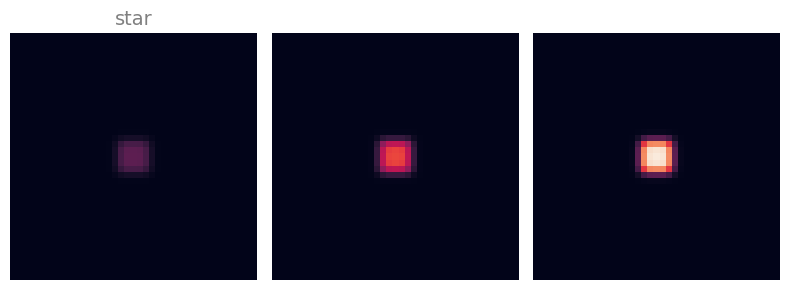

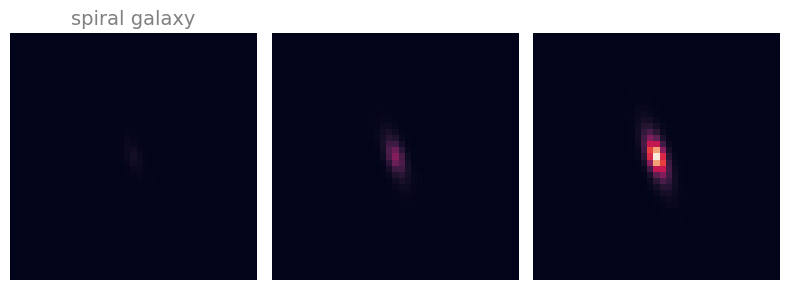

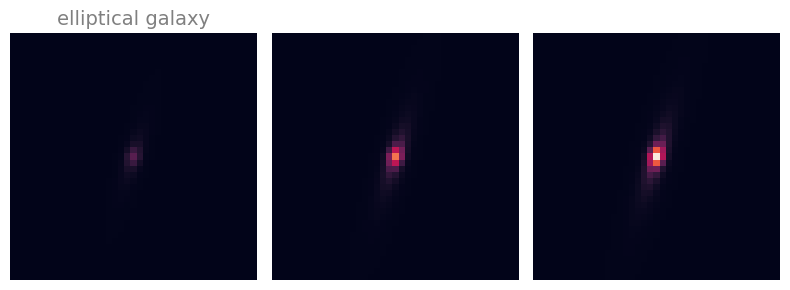

In [5]:
with np.load('data/galaxy_cubes.npz') as data:
    images = data['images']
    galaxy_labels = data['labels']

print([images.shape, galaxy_labels.shape])

show_images(images,galaxy_labels)

## Add white noise to observations


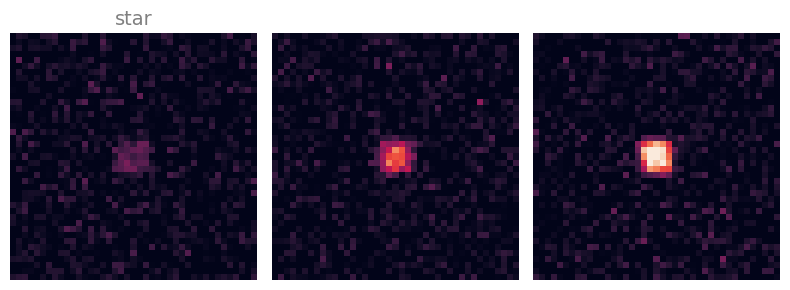

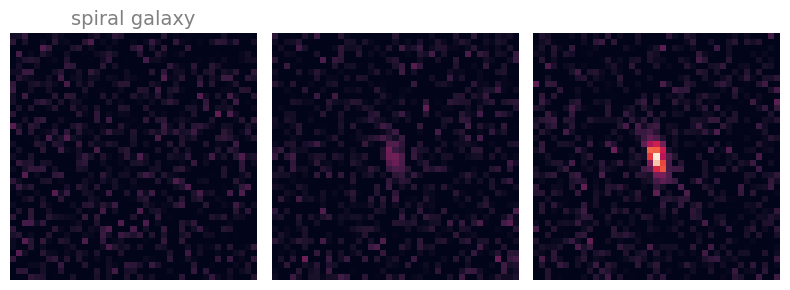

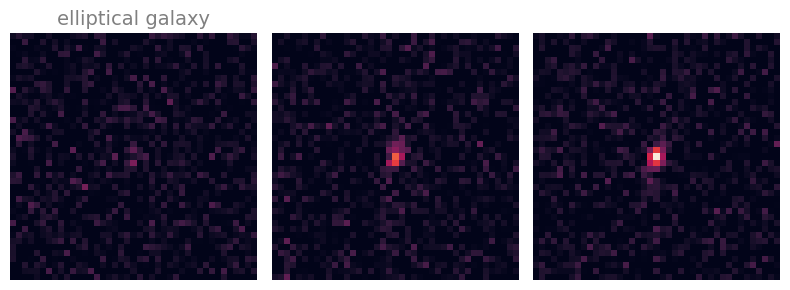

In [6]:
images= images+np.random.randn(10000,41,41,3)*20
images= np.clip(images, 0, 255)

show_images(images,galaxy_labels)

## Create training and testing (validation) dataset


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Split the sample into train/validation/test
    
</div>


_HINT:_ to test various architectures fast keep the train/test sizes rather **small**, i.e. use a huge fraction for test to get a very small number for train+validation (a few hundrends). At the end you would like to retrain with the **full dataset** (that will take some time).

In [7]:
# using two times the train_test_split to get initially
# the test sample and then train and validation.
#
# you can use random_state if you want to reproduce the same exact splits
# and shuffle if you want to mix the data before splits

X_train_full, X_test_img, y_train_full_lbl, y_test_lbl = train_test_split(
        images,galaxy_labels, test_size= 0.95) #, shuffle = True, random_state=42)

# split into train and validation
X_train_img, X_valid_img, y_train_lbl, y_valid_lbl = train_test_split(
        X_train_full , y_train_full_lbl , test_size= 0.3) #, shuffle = True, random_state=24 )

print(f'From {len(images)} images, we use as:')
print(f'test: \t\t {len(X_test_img)}')
print(f'train: \t\t  {len(X_train_img)}')
print(f'validation:\t  {len(X_valid_img)}')

# NOTE: this is a data manipulation as keras needs the number of objects
# with properties at each "channel", and their correspoding number.
# As keras thinks of images as RGB it uses 3 as last number.
# To avoid keras to assume anything add specifically ',1' at the end.

X_train = X_train_img.reshape(len(X_train_img), images.shape[1],images.shape[2],images.shape[3],1)
X_valid = X_valid_img.reshape(len(X_valid_img), images.shape[1],images.shape[2],images.shape[3],1)
X_test  = X_test_img.reshape(len(X_test_img), images.shape[1],images.shape[2],images.shape[3],1)


# NOTE: converting labels to categorical representation,
# a vector whose position indicates its class
# 0: star, ---------------> [1, 0, 0]
# 1: spiral galaxy, ------> [0, 1, 0]
# 2: elliptical galaxy ---> [0, 0, 1]
y_train = ult.to_categorical(y_train_lbl,num_classes=3)
y_valid = ult.to_categorical(y_valid_lbl,num_classes=3)
y_test  = ult.to_categorical(y_test_lbl,num_classes=3)


From 10000 images, we use as:
test: 		 9500
train: 		  350
validation:	  150


## Define network layers and characteristics


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Build the CNN model.
    
- For this you need to apply a set of different CNN layers along with others such as pooling, dropout, etc.
    
- Feel free to play around with the number and types of layers. Also adjust the number of nodes per layer, kernel size and strides.
    
- How many nodes the last layer should have?
    
</div>

The functional form to write the layers would be equivalent to this:

```python
inputs = Input((images.shape[1], images.shape[2], images.shape[3], 1),name='main_input')

conv00  = Conv3D( ... , (3, 3, 2), strides=(1, 1, 1), padding='same', name='conv00')(inputs)
act00 = Activation('relu')(conv00)
pool00  = MaxPooling3D(pool_size=(3, 3, 1), strides=(2, 2, 1), padding='same')(act00)
drop00 = Dropout(0.3)(pool00)

... more layers ...


fl0 = Flatten(name='fl0')(pool20)
fc0 = Dense(32,activation='linear')(fl0)

... more layers ...

# do not remove!
Dn0 = Dense( ... , activation='softmax', name='Dn0' )(fc0)

my_model = Model(inputs=[inputs], outputs=[Dn0])
```

However, we can simplify this by performing all actions on the same variable, so that we do not get lost with all these variable names.

In [16]:
inputs = Input(shape=(images.shape[1], images.shape[2], images.shape[3], 1))

x = Conv3D( 16 ,  (3,3,2), strides=(1, 1, 1), padding='same')(inputs)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

x = Conv3D( 16 ,  (3,3,2), strides=(1, 1, 1), padding='same')(inputs)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

x = Conv3D( 16 ,  (3,3,2), strides=(1, 1, 1), padding='same')(inputs)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

#... more layers ... ?

x = Dropout(0.3)(x)

# do not remove this
x = Flatten()(x)
x = Dense( 32, activation='relu')(x)

#... more layers ... ?

out = Dense( 3 , activation='softmax')(x)

my_model = Model(inputs=[inputs], outputs=[out])


In [17]:
Dense?

Selecting Adam optimizer to compile the model.

_HINT:_ check the documentation ([keras:accuracy_metrics](https://keras.io/api/metrics/accuracy_metrics/)) and remember that we are using the categorical labels.


In [18]:
my_model.compile(loss='categorical_crossentropy',
                 optimizer=Adam(learning_rate=1e-4),
                 metrics =['categorical_accuracy'])
my_model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 41, 41, 3, 1)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_6 (Conv3D)               │ (None, 41, 41, 3, 16)  │           304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 41, 41, 3, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling3d_6 (MaxPooling3D)  │ (None, 21, 21, 3, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 21, 21, 3, 16)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 21168)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 32)             │       677,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 677,811 (2.59 MB)

 Trainable params: 677,811 (2.59 MB)

 Non-trainable params: 0 (0.00 B)

## Train the network


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** Fill the missing code to train the model
    
</div>

_HINT:_ You may increase the **batch_size**, and decrease the number of **epochs**, when testing in order to minimize the training time.

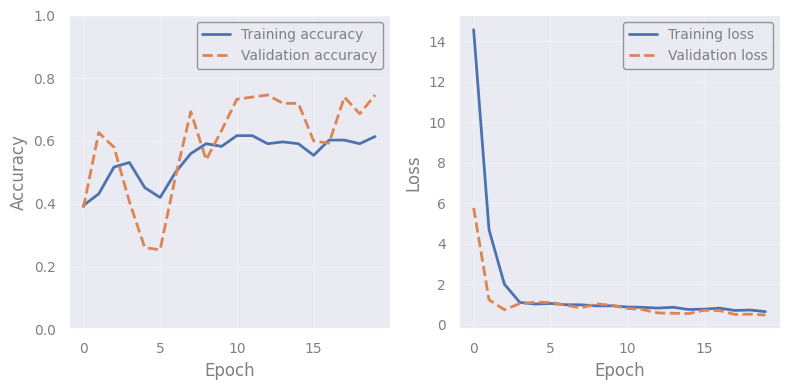

6/6 ━━━━━━━━━━━━━━━━━━━━ 10s 968ms/step - categorical_accuracy: 0.6143 - loss: 0.6348 - val_categorical_accuracy: 0.7467 - val_loss: 0.4697


'00:03:03'

In [19]:
start_time = time.time()

history=my_model.fit( X_train, y_train ,
                    batch_size= 64,
                    epochs= 20,
                    validation_data=[ X_valid, y_valid ],
                    callbacks=[plot_losses],shuffle=True)

elapsed_time = time.time() - start_time
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

## Check performance


<div style="border-left: 5px solid #FFA500; background-color: rgba(255, 165, 0, 0.15); padding: 10px; border-radius: 4px; color: inherit;">

**Task:** evaluate the model (take care on which dataset!)
    
</div>

_HINT_: if you want to speed up the process a bit select the number of TO objects of the test set (eg first 100).


In [20]:
TO = len( X_test ) # or smaller...

ls,acc=my_model.evaluate( X_test[0:TO], y_test[0:TO])
print("Loss value: %.2f" % (ls))
print("Accuracy: %.1f" % (acc*100))

297/297 ━━━━━━━━━━━━━━━━━━━━ 30s 102ms/step - categorical_accuracy: 0.6674 - loss: 0.5230
Loss value: 0.52
Accuracy: 66.7


## Predict label for particular example


In [ ]:
# select object
obj = 33        # must be less than len( X_test)

preds = my_model.predict( X_test[obj:obj+1,:,:,:,:])
print(f"Probability per class: {', '.join([str(i*100)[0:5]+'%' for i in preds[0]])}")
print(f'Highest for class: {label_trans( np.argmax(preds))}')


## Print the activations for particular inputs


Using `model.layers` we print all layers of the model.


In [ ]:
my_model.layers

We can select for which one to print the activations.

_HINT: select convolutional layers to check them.


In [ ]:
sel_layer = 1  # eg 1

my_model.layers[sel_layer]

Selecting a random sample to present.

_HINT: to avoid issues with plots check that the number of nodes in the concolution layer is properly trasnfered to the plotting for-loop of activation layers_

_Compare this with what we see with the [CNN explainer](https://poloclub.github.io/cnn-explainer/).


In [ ]:
s = np.random.randint(0,len(X_test)-1)

plt.imshow(X_test[s,:,:,0,0])
plt.title(f'Input image index: {s}')
plt.show()

# using the specific layer as an output
lr = my_model.layers[sel_layer].output
activation_model_lr = Model(inputs=[inputs], outputs=lr)

# extracting the activations of specific layer (as a model)
activations_lr = activation_model_lr.predict( X_test[s:s+1,:,:,:,:])

# NOTE: check the number of nodes in the CNN
for i in np.arange(16):
    img=activations_lr[0,:,:,0,i]
    plt.imshow(img)
    plt.title('Number ' + str(i))
    plt.show()
plt.show()

---


# Solutions


<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[Solution below]</b>

</div>

In [ ]:
# using two times the train_test_split to get initially
# the test sample and then train and validation.
#
# you can use random_state if you want to reproduce the same exact splits
# and shuffle if you want to mix the data before splits

X_train_full, X_test_img, y_train_full_lbl, y_test_lbl = train_test_split(
        images , galaxy_labels, test_size=0.95) #, shuffle = True, random_state=42)

# split into train and validation
X_train_img, X_valid_img, y_train_lbl, y_valid_lbl = train_test_split(
        X_train_full , y_train_full_lbl , test_size=0.3) #, shuffle = True, random_state=24 )

print(f'From {len(images)} images, we use as:')
print(f'test: \t\t {len(X_test_img)}')
print(f'train: \t\t  {len(X_train_img)}')
print(f'validation:\t  {len(X_valid_img)}')

# NOTE: this is a data manipulation as keras needs the number of objects
# with properties at each "channel", and their correspoding number.
# As keras thinks of images as RGB it uses 3 as last number.
# To avoid keras to assume anything add specifically ',1' at the end.

X_train = X_train_img.reshape(len(X_train_img), images.shape[1],images.shape[2],images.shape[3],1)
X_valid = X_valid_img.reshape(len(X_valid_img), images.shape[1],images.shape[2],images.shape[3],1)
X_test  = X_test_img.reshape(len(X_test_img), images.shape[1],images.shape[2],images.shape[3],1)


# NOTE: converting labels to categorical representation,
# a vector whose position indicates its class
# 0: star, ---------------> [1, 0, 0]
# 1: spiral galaxy, ------> [0, 1, 0]
# 2: elliptical galaxy ---> [0, 0, 1]
y_train = ult.to_categorical(y_train_lbl,num_classes=3)
y_valid = ult.to_categorical(y_valid_lbl,num_classes=3)
y_test  = ult.to_categorical(y_test_lbl,num_classes=3)


In [ ]:
inputs = Input(shape=(images.shape[1], images.shape[2], images.shape[3], 1))

x = Conv3D(16,   (3,3,2), strides=(1, 1, 1), padding='same')(inputs)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

x = Conv3D(32,  (3,3,2), strides=(1, 1, 1), padding='same')(x)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

x = Conv3D(128,  (3,3,2), strides=(1, 1, 1), padding='same')(x)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

x = Conv3D(256,  (3,3,2), strides=(1, 1, 1), padding='same')(x)
x = Activation('relu')(x)
x = MaxPooling3D(pool_size=(3,3,1), strides=(2,2,1), padding='same')(x)

x = Dropout(0.3)(x)
x = Flatten()(x)

x = Dense(32, activation='relu')(x)
x = Dense(8, activation='relu')(x)
Dn0 = Dense(3, activation='softmax')(x)

my_model = Model(inputs=[inputs], outputs=[Dn0])


In [ ]:
my_model.compile(loss='categorical_crossentropy',
                 optimizer=Adam(learning_rate=1e-4),
                 metrics =['categorical_accuracy'])
my_model.summary()

In [ ]:
start_time = time.time()

history=my_model.fit( X_train , y_train ,
                    batch_size= 32,
                    epochs= 20,
                    validation_data=[ X_valid , y_valid ],
                    callbacks=[plot_losses],shuffle=True)

elapsed_time = time.time() - start_time
time.strftime("%H:%M:%S", time.gmtime(elapsed_time))

In [ ]:
TO = len(X_test) # or smaller...

ls,acc=my_model.evaluate( X_test[0:TO], y_test[0:TO])
print("Loss value: %.2f" % (ls))
print("Accuracy: %.1f" % (acc*100))

<div class="alert alert-danger" role="alert" style="border-radius: 8px; padding: 10px;">
    
<b>[End of solution]</b>

</div>

In [ ]:
###EOF